# GRAPE on a single spin

This in an introductory example to the [GRAPE](10.1016/j.jmr.2004.11.004) method and its implementation in this software package.

#### 1. Generate a PWC pulse shape

In [1]:
import matplotlib.pyplot as plt
import numpy as np
from cthree.quantity import Quantity

from cthree.signal.envelopes import GaussEnvelope
from cthree.signal.pwc_generator import PWCGenerator

First, let's generate a piecewise constant (PWC) pulse envelope for the Gaussian pulse. For GRAPE, we need to specify an anstanz for piecewise constant controls at a given resolution. Here, we setup a Gaussian initial guess, sampling at 21 points during a gate time of 20ns.

In [3]:
t_final = 20e-9
tlist = np.linspace(0, t_final, 21)
tone = GaussEnvelope(amplitude=Quantity(np.pi / t_final / 3, -np.pi / t_final, np.pi / t_final))
tone.t_final.set_value(t_final)
gen = PWCGenerator(envelopes=[tone], tlist=tlist)
gen.multiply_flat_top = True

We have added the option `multiplyFlatTop`, to ensure the pulse to start and end smoothly at 0 and `t_final`.

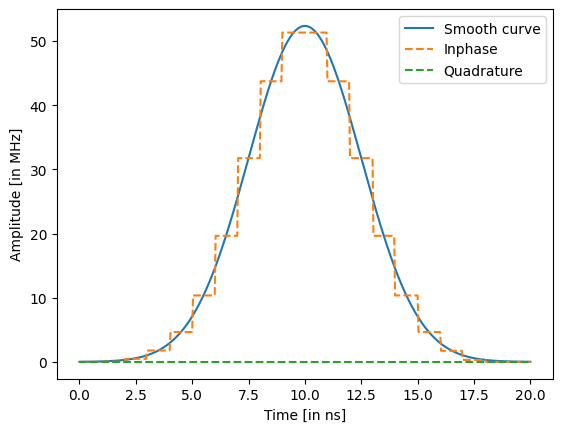

In [4]:
ts = np.linspace(0, t_final, 501)

plt.plot(ts / 1e-9, tone.compute_output(ts) / 1e6, label="Smooth curve")
plt.plot(ts / 1e-9, np.real(gen.generate_signal(ts)) / 1e6, ls="--", label="Inphase")
plt.plot(
    ts / 1e-9,
    np.imag(gen.generate_signal(ts)) / 1e6,
    ls="--",
    label="Quadrature",
)

plt.xlabel("Time [in ns]")
plt.ylabel("Amplitude [in MHz]")
plt.legend()

#### 2. Define Hamiltonian in the rotating frame of drive

As a simple toy model, we use a single spin.

In [5]:
from cthree.model.closed_system import ClosedSystem
from cthree.model.rotating_frame_drive import RotatingFrameDrive
from cthree.model.hamiltonian import Hamiltonian


class SpinRWA(Hamiltonian):
    """A Single Spin."""

    def __init__(self, drives=None):
        super().__init__(drives)
        self.sigma_p = np.array([[0j, 1], [0, 0]])
        self.dim = 2

    def get_matrix_one_time(self, t):
        """Just sigma-X."""
        return self._drives[0].get_matrix_one_time(self.sigma_p, t)

    def gradient(self, t):
        """Gradient is just the drive matrix."""
        return self._drives[0].gradient(self.sigma_p, t)


drive = RotatingFrameDrive(gen)
spin = SpinRWA(drives=[drive])
model = ClosedSystem(spin)

In [6]:
from cthree.measurement.state_transfer_fidelity import StateTransferFidelityGRAPE
from cthree.propagation.scipy_expm_grape import ScipyExpmGRAPE


prop = ScipyExpmGRAPE(model, res=1e9)

init = np.array([[1.0], [0]])  # |0>
target = np.array([[0.0], [1]])  # |1>

prop.set_initial_state(init)
prop.set_target_state(target)

zeroone = StateTransferFidelityGRAPE(
    propagation=prop,
    initial_state=init,
    target_state=target,
    times=tlist,
)

(<Figure size 400x400 with 2 Axes>,
 array([<Axes: ylabel='Field [MHz]'>,
        <Axes: xlabel='Time [ns]', ylabel='Population'>], dtype=object))

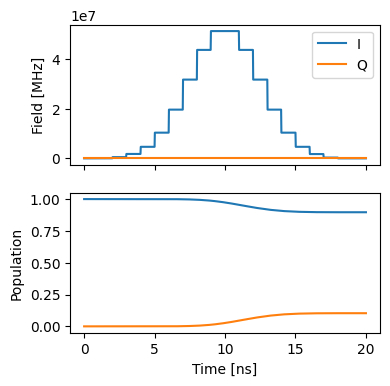

In [7]:
def plotStates():
    """Plot the states."""
    ts = np.linspace(0, t_final, 1001)
    states = prop.propagate(ts)
    sig = gen.generate_signal(ts)

    fig, ax = plt.subplots(2, figsize=(4, 4), sharex=True)
    ax[0].plot(ts / 1e-9, np.real(sig), label="I")
    ax[0].plot(ts / 1e-9, np.imag(sig), label="Q")
    ax[0].legend(loc=1)
    ax[0].set_ylabel("Field [MHz]")
    ax[1].plot(ts / 1e-9, np.abs(states)[:, :, 0] ** 2)
    ax[1].set_ylabel("Population")
    ax[-1].set_xlabel("Time [ns]")
    return fig, ax


plotStates()

In [8]:
from cthree.optimisation_map import OptimisationMap
from cthree.optimisers.scipy_optimiser_gradient import ScipyOptimiserGradient


optmap = OptimisationMap()
optmap.add(gen)
optmap.register_params_with_optimisables()

optGrad = ScipyOptimiserGradient(zeroone, optimisables=optmap)

In [9]:
optGrad.optimise()

RUNNING THE L-BFGS-B CODE

           * * *

Machine precision = 2.220D-16
 N =           40     M =           10

At X0         0 variables are exactly at the bounds

At iterate    0    f=  8.96633D-01    |proj g|=  6.24987D-02

At iterate    1    f=  8.31187D-01    |proj g|=  7.68997D-02
  ys=-1.348E-02  -gs= 5.850E-02 BFGS update SKIPPED

At iterate    2    f=  2.08977D-01    |proj g|=  8.34673D-02
  ys=-4.304E-02  -gs= 5.039E-01 BFGS update SKIPPED

At iterate    3    f=  1.27778D-01    |proj g|=  6.85353D-02

At iterate    4    f=  2.05252D-03    |proj g|=  9.26818D-03

At iterate    5    f=  1.04341D-03    |proj g|=  6.43917D-03

At iterate    6    f=  6.86749D-04    |proj g|=  4.52112D-03

At iterate    7    f=  3.45918D-04    |proj g|=  3.20928D-03

At iterate    8    f=  9.30259D-05    |proj g|=  1.06148D-03

At iterate    9    f=  6.32441D-05    |proj g|=  8.75242D-04

At iterate   10    f=  8.08686D-13    |proj g|=  1.84764D-07

           * * *

Tit   = total number of iter

{'status': 1, 'value': 8.08686451136964e-13, 'iterations': 14, 'message': 'CONVERGENCE: NORM_OF_PROJECTED_GRADIENT_<=_PGTOL'}


   N    Tit     Tnf  Tnint  Skip  Nact     Projg        F
   40     10     14     23     2    15   1.848D-07   8.087D-13
  F =   8.0868645113696402E-013

CONVERGENCE: NORM_OF_PROJECTED_GRADIENT_<=_PGTOL            


For this simple example, we reach near perfect fidelity within a few iterations.

(<Figure size 400x400 with 2 Axes>,
 array([<Axes: ylabel='Field [MHz]'>,
        <Axes: xlabel='Time [ns]', ylabel='Population'>], dtype=object))

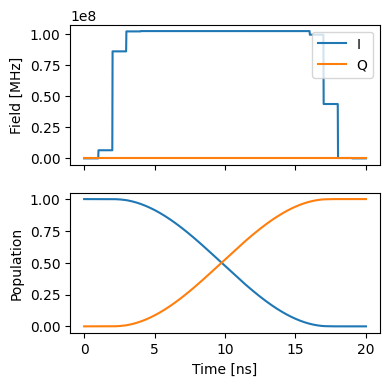

In [10]:
plotStates()